In [1]:
from pathlib import Path

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

In [2]:
current_dir = Path.cwd()

if current_dir.name == "notebooks":
    PROJECT_ROOT = current_dir.parent
else:
    PROJECT_ROOT = current_dir

PREPROCESSED_DATA_PATH = PROJECT_ROOT / "data" / "processed" / "shopee_absa_preprocessed.csv"

TRAIN_PATH = PROJECT_ROOT / "data" / "processed" / "train.csv"
TEST_PATH = PROJECT_ROOT / "data" / "processed" / "test.csv"

RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

SPLIT_SUMMARY_PATH = RESULTS_DIR / "split_summary.csv"

print("Project root:", PROJECT_ROOT)
print("Preprocessed data path:", PREPROCESSED_DATA_PATH)
print("Train path:", TRAIN_PATH)
print("Test path:", TEST_PATH)

Project root: d:\Workspace\b2\Machine learning 1\shopee-absa-ml-project
Preprocessed data path: d:\Workspace\b2\Machine learning 1\shopee-absa-ml-project\data\processed\shopee_absa_preprocessed.csv
Train path: d:\Workspace\b2\Machine learning 1\shopee-absa-ml-project\data\processed\train.csv
Test path: d:\Workspace\b2\Machine learning 1\shopee-absa-ml-project\data\processed\test.csv


In [3]:
df = pd.read_csv(PREPROCESSED_DATA_PATH, encoding="utf-8-sig")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (2466, 6)


,comment,chat_luong,dong_goi,van_chuyen,gia_ca,clean_comment
0,Chất lượng sản phẩm: dày dặn... màu tô khác hình,negative,negative,neutral,neutral,chất lượng sản phẩm dày dặn màu tô khác hình
1,"Chưa dùng... đóng gói cẩn thận, giao nhanh",positive,positive,positive,neutral,chưa dùng đóng gói cẩn thận giao nhanh
2,Bài viết JISOO...,neutral,neutral,neutral,neutral,bài viết jisoo
3,"Đẹp, màu xinh, khó tô",negative,neutral,neutral,neutral,đẹp màu xinh khó tô
4,Sản phẩm móp méo,negative,negative,neutral,neutral,sản phẩm móp méo


In [4]:
required_columns = [
    "comment",
    "clean_comment",
    "chat_luong",
    "dong_goi",
    "van_chuyen",
    "gia_ca"
]

missing_columns = [col for col in required_columns if col not in df.columns]

if missing_columns:
    raise ValueError(f"Missing columns: {missing_columns}")
else:
    print("All required columns are available.")

All required columns are available.


In [5]:
df[required_columns].isna().sum()

comment          0
clean_comment    0
chat_luong       0
dong_goi         0
van_chuyen       0
gia_ca           0
dtype: int64

In [6]:
TEXT_COLUMN = "clean_comment"

aspect_columns = [
    "chat_luong",
    "dong_goi",
    "van_chuyen",
    "gia_ca"
]

label_order = ["positive", "negative", "neutral"]

X = df[TEXT_COLUMN]
y = df[aspect_columns]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (2466,)
y shape: (2466, 4)


In [7]:
df["combined_label"] = (
    df["chat_luong"].astype(str) + "_" +
    df["dong_goi"].astype(str) + "_" +
    df["van_chuyen"].astype(str) + "_" +
    df["gia_ca"].astype(str)
)

combined_counts = df["combined_label"].value_counts()

print("Number of unique combined labels:", combined_counts.shape[0])
combined_counts.head(10)

Number of unique combined labels: 53


combined_label
negative_neutral_neutral_neutral      763
positive_neutral_neutral_neutral      328
negative_negative_neutral_neutral     303
positive_neutral_positive_neutral     138
positive_positive_positive_neutral    121
positive_neutral_neutral_positive     111
neutral_neutral_neutral_neutral        72
positive_positive_neutral_neutral      70
negative_neutral_neutral_positive      58
positive_neutral_positive_positive     57
Name: count, dtype: int64

In [11]:
min_combined_count = combined_counts.min()

print("Minimum combined label count:", min_combined_count)

Minimum combined label count: 1


In [12]:
RANDOM_STATE = 42
TEST_SIZE = 0.2

if min_combined_count >= 2:
    print("Using stratified split based on combined labels.")

    train_df, test_df = train_test_split(
        df,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        shuffle=True,
        stratify=df["combined_label"]
    )

else:
    print("Some combined labels appear only once.")
    print("Using normal random split without stratification.")

    train_df, test_df = train_test_split(
        df,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        shuffle=True,
        stratify=None
    )

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Some combined labels appear only once.
Using normal random split without stratification.
Train shape: (1972, 7)
Test shape: (494, 7)


In [13]:
train_df = train_df.drop(columns=["combined_label"], errors="ignore")
test_df = test_df.drop(columns=["combined_label"], errors="ignore")

print("Train columns:", train_df.columns.tolist())
print("Test columns:", test_df.columns.tolist())

Train columns: ['comment', 'chat_luong', 'dong_goi', 'van_chuyen', 'gia_ca', 'clean_comment']
Test columns: ['comment', 'chat_luong', 'dong_goi', 'van_chuyen', 'gia_ca', 'clean_comment']


In [14]:
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

train_df.head()

,comment,chat_luong,dong_goi,van_chuyen,gia_ca,clean_comment
0,mỏng rộng,negative,neutral,neutral,neutral,mỏng rộng
1,nhỏ gọn chắc chắn. đóng gói cẩn thận,negative,positive,neutral,neutral,nhỏ gọn chắc chắn đóng gói cẩn thận
2,tập to bị móp góc,negative,negative,neutral,neutral,tập to bị móp góc
3,đóng gói sơ sài vận chuyển cong nhẹ,negative,negative,negative,neutral,đóng gói sơ sài vận chuyển cong nhẹ
4,sơ sài khác ảnh bị móp không vừa,negative,neutral,neutral,neutral,sơ sài khác ảnh bị móp không vừa


In [15]:
total_rows = len(train_df) + len(test_df)

train_ratio = len(train_df) / total_rows
test_ratio = len(test_df) / total_rows

print("Total rows:", total_rows)
print("Train rows:", len(train_df))
print("Test rows:", len(test_df))
print("Train ratio:", round(train_ratio, 4))
print("Test ratio:", round(test_ratio, 4))

Total rows: 2466
Train rows: 1972
Test rows: 494
Train ratio: 0.7997
Test ratio: 0.2003


In [16]:
def get_label_distribution(dataframe, aspect_columns, label_order):
    distribution = []

    for aspect in aspect_columns:
        counts = dataframe[aspect].value_counts(normalize=True).reindex(label_order, fill_value=0) * 100

        for label in label_order:
            distribution.append({
                "aspect": aspect,
                "label": label,
                "percentage": counts[label]
            })

    return pd.DataFrame(distribution)

In [17]:
full_distribution = get_label_distribution(df, aspect_columns, label_order)
train_distribution = get_label_distribution(train_df, aspect_columns, label_order)
test_distribution = get_label_distribution(test_df, aspect_columns, label_order)

full_distribution["split"] = "full"
train_distribution["split"] = "train"
test_distribution["split"] = "test"

split_distribution = pd.concat(
    [full_distribution, train_distribution, test_distribution],
    ignore_index=True
)

split_distribution["percentage"] = split_distribution["percentage"].round(2)

split_distribution.head(20)

,aspect,label,percentage,split
0,chat_luong,positive,36.46,full
1,chat_luong,negative,58.56,full
2,chat_luong,neutral,4.99,full
3,dong_goi,positive,15.00,full
4,dong_goi,negative,16.63,full
5,dong_goi,neutral,68.37,full
6,van_chuyen,positive,19.83,full
7,van_chuyen,negative,3.65,full
8,van_chuyen,neutral,76.52,full
9,gia_ca,positive,13.95,full


In [18]:
split_distribution_pivot = split_distribution.pivot_table(
    index=["aspect", "label"],
    columns="split",
    values="percentage"
).reset_index()

split_distribution_pivot = split_distribution_pivot[
    ["aspect", "label", "full", "train", "test"]
]

split_distribution_pivot

split,aspect,label,full,train,test
0,chat_luong,negative,58.56,58.47,58.91
1,chat_luong,neutral,4.99,4.92,5.26
2,chat_luong,positive,36.46,36.61,35.83
3,dong_goi,negative,16.63,16.58,16.80
4,dong_goi,neutral,68.37,68.51,67.81
5,dong_goi,positive,15.00,14.91,15.38
6,gia_ca,negative,2.39,2.43,2.23
7,gia_ca,neutral,83.66,83.72,83.40
8,gia_ca,positive,13.95,13.84,14.37
9,van_chuyen,negative,3.65,4.16,1.62


In [19]:
split_distribution_pivot.to_csv(
    SPLIT_SUMMARY_PATH,
    index=False,
    encoding="utf-8-sig"
)

print("Saved split summary to:", SPLIT_SUMMARY_PATH)

Saved split summary to: d:\Workspace\b2\Machine learning 1\shopee-absa-ml-project\results\split_summary.csv


In [20]:
train_df.to_csv(TRAIN_PATH, index=False, encoding="utf-8-sig")
test_df.to_csv(TEST_PATH, index=False, encoding="utf-8-sig")

print("Saved train set to:", TRAIN_PATH)
print("Saved test set to:", TEST_PATH)

Saved train set to: d:\Workspace\b2\Machine learning 1\shopee-absa-ml-project\data\processed\train.csv
Saved test set to: d:\Workspace\b2\Machine learning 1\shopee-absa-ml-project\data\processed\test.csv


In [21]:
X_train = train_df["clean_comment"]
X_test = test_df["clean_comment"]

y_train = train_df[aspect_columns]
y_test = test_df[aspect_columns]

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1972,)
X_test shape: (494,)
y_train shape: (1972, 4)
y_test shape: (494, 4)


In [22]:
from pathlib import Path

import pandas as pd
import numpy as np
import joblib

from sklearn.feature_extraction.text import TfidfVectorizer

In [29]:
current_dir = Path.cwd()

if current_dir.name == "notebooks":
    PROJECT_ROOT = current_dir.parent
else:
    PROJECT_ROOT = current_dir

TRAIN_PATH = PROJECT_ROOT / "data" / "processed" / "train.csv"
TEST_PATH = PROJECT_ROOT / "data" / "processed" / "test.csv"

MODELS_DIR = PROJECT_ROOT / "models"
RESULTS_DIR = PROJECT_ROOT / "results"

MODELS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

TFIDF_VECTORIZER_PATH = MODELS_DIR / "tfidf_vectorizer.pkl"
TFIDF_SUMMARY_PATH = RESULTS_DIR / "tfidf_summary.csv"
TFIDF_FEATURE_NAMES_PATH = RESULTS_DIR / "tfidf_feature_names.csv"

print("Train path:", TRAIN_PATH)
print("Test path:", TEST_PATH)
print("Vectorizer path:", TFIDF_VECTORIZER_PATH)

Train path: d:\Workspace\b2\Machine learning 1\shopee-absa-ml-project\data\processed\train.csv
Test path: d:\Workspace\b2\Machine learning 1\shopee-absa-ml-project\data\processed\test.csv
Vectorizer path: d:\Workspace\b2\Machine learning 1\shopee-absa-ml-project\models\tfidf_vectorizer.pkl


In [23]:
train_df = pd.read_csv(TRAIN_PATH, encoding="utf-8-sig")
test_df = pd.read_csv(TEST_PATH, encoding="utf-8-sig")

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

train_df.head()

Train shape: (1972, 6)
Test shape: (494, 6)


,comment,chat_luong,dong_goi,van_chuyen,gia_ca,clean_comment
0,mỏng rộng,negative,neutral,neutral,neutral,mỏng rộng
1,nhỏ gọn chắc chắn. đóng gói cẩn thận,negative,positive,neutral,neutral,nhỏ gọn chắc chắn đóng gói cẩn thận
2,tập to bị móp góc,negative,negative,neutral,neutral,tập to bị móp góc
3,đóng gói sơ sài vận chuyển cong nhẹ,negative,negative,negative,neutral,đóng gói sơ sài vận chuyển cong nhẹ
4,sơ sài khác ảnh bị móp không vừa,negative,neutral,neutral,neutral,sơ sài khác ảnh bị móp không vừa


In [24]:
TEXT_COLUMN = "clean_comment"

aspect_columns = [
    "chat_luong",
    "dong_goi",
    "van_chuyen",
    "gia_ca"
]

X_train = train_df[TEXT_COLUMN].fillna("")
X_test = test_df[TEXT_COLUMN].fillna("")

y_train = train_df[aspect_columns]
y_test = test_df[aspect_columns]

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1972,)
X_test shape: (494,)
y_train shape: (1972, 4)
y_test shape: (494, 4)


In [25]:
vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("X_train_tfidf shape:", X_train_tfidf.shape)
print("X_test_tfidf shape:", X_test_tfidf.shape)

X_train_tfidf shape: (1972, 3084)
X_test_tfidf shape: (494, 3084)


In [26]:
feature_names = vectorizer.get_feature_names_out()

print("Number of TF-IDF features:", len(feature_names))
print("First 50 features:")
print(feature_names[:50])

Number of TF-IDF features: 3084
First 50 features:
['10' '10 ngày' '12' '15' '150gb' '16' '16 plus' '1k' '25' '2g' '30' '30k'
 '360' '360 độ' '3g' '4g' '4g tháng' '4gb' '4gb không' '6mm' '6s' '8mm'
 '8mm giao' '9k' 'an' 'anh' 'anh em' 'app' 'ban' 'bao' 'bao bì' 'bao giờ'
 'bao tay' 'biết' 'biết bền' 'biết chất' 'biết có' 'biết do' 'biết dùng'
 'biết thế' 'bo' 'bong' 'bong tróc' 'bung' 'bung chất' 'bung chỉ'
 'bung chỗ' 'bung dù' 'bung luôn' 'bung ra']


In [27]:
important_terms = [
    "giao hàng",
    "đóng gói",
    "giá rẻ",
    "không tốt",
    "không đáng",
    "giao chậm",
    "sản phẩm",
    "chất lượng",
    "đắt",
    "rẻ",
    "móp méo",
    "sai hàng"
]

vocab = set(feature_names)

for term in important_terms:
    if term in vocab:
        print(f"FOUND: {term}")
    else:
        print(f"NOT FOUND: {term}")

FOUND: giao hàng
FOUND: đóng gói
FOUND: giá rẻ
FOUND: không tốt
FOUND: không đáng
FOUND: giao chậm
FOUND: sản phẩm
FOUND: chất lượng
FOUND: đắt
FOUND: rẻ
FOUND: móp méo
FOUND: sai hàng


In [30]:
feature_names_df = pd.DataFrame({
    "feature": feature_names
})

feature_names_df.to_csv(
    TFIDF_FEATURE_NAMES_PATH,
    index=False,
    encoding="utf-8-sig"
)

print("Saved TF-IDF feature names to:", TFIDF_FEATURE_NAMES_PATH)

Saved TF-IDF feature names to: d:\Workspace\b2\Machine learning 1\shopee-absa-ml-project\results\tfidf_feature_names.csv


In [32]:
tfidf_summary = pd.DataFrame([
    {
        "setting": "ngram_range",
        "value": str(vectorizer.ngram_range)
    },
    {
        "setting": "min_df",
        "value": vectorizer.min_df
    },
    {
        "setting": "max_df",
        "value": vectorizer.max_df
    },
    {
        "setting": "number_of_train_samples",
        "value": X_train_tfidf.shape[0]
    },
    {
        "setting": "number_of_test_samples",
        "value": X_test_tfidf.shape[0]
    },
    {
        "setting": "number_of_tfidf_features",
        "value": X_train_tfidf.shape[1]
    }
])

tfidf_summary

,setting,value
0,ngram_range,"(1, 2)"
1,min_df,2
2,max_df,0.95
3,number_of_train_samples,1972
4,number_of_test_samples,494
5,number_of_tfidf_features,3084


In [33]:
tfidf_summary.to_csv(
    TFIDF_SUMMARY_PATH,
    index=False,
    encoding="utf-8-sig"
)

print("Saved TF-IDF summary to:", TFIDF_SUMMARY_PATH)

Saved TF-IDF summary to: d:\Workspace\b2\Machine learning 1\shopee-absa-ml-project\results\tfidf_summary.csv


In [34]:
joblib.dump(vectorizer, TFIDF_VECTORIZER_PATH)

print("Saved TF-IDF vectorizer to:", TFIDF_VECTORIZER_PATH)

Saved TF-IDF vectorizer to: d:\Workspace\b2\Machine learning 1\shopee-absa-ml-project\models\tfidf_vectorizer.pkl


In [35]:
loaded_vectorizer = joblib.load(TFIDF_VECTORIZER_PATH)

sample_texts = [
    "giao hàng nhanh đóng gói kỹ nhưng sản phẩm hơi đắt"
]

sample_tfidf = loaded_vectorizer.transform(sample_texts)

print("Sample TF-IDF shape:", sample_tfidf.shape)

Sample TF-IDF shape: (1, 3084)


In [36]:
print(type(X_train_tfidf))
print(type(X_test_tfidf))

<class 'scipy.sparse._csr.csr_matrix'>
<class 'scipy.sparse._csr.csr_matrix'>


In [37]:
sample_index = 0

sample_comment = X_train.iloc[sample_index]
sample_vector = X_train_tfidf[sample_index]

nonzero_indices = sample_vector.nonzero()[1]
nonzero_values = sample_vector.data

sample_features = pd.DataFrame({
    "feature": feature_names[nonzero_indices],
    "tfidf_value": nonzero_values
}).sort_values(by="tfidf_value", ascending=False)

print("Sample comment:")
print(sample_comment)

sample_features.head(20)

Sample comment:
mỏng rộng


,feature,tfidf_value
1,rộng,0.836105
0,mỏng,0.548570


In [38]:
from pathlib import Path

import pandas as pd
import numpy as np
import joblib

from sklearn.linear_model import LogisticRegression

In [39]:
current_dir = Path.cwd()

if current_dir.name == "notebooks":
    PROJECT_ROOT = current_dir.parent
else:
    PROJECT_ROOT = current_dir

MODELS_DIR = PROJECT_ROOT / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print("Models directory:", MODELS_DIR)

Models directory: d:\Workspace\b2\Machine learning 1\shopee-absa-ml-project\models


In [40]:
print("X_train_tfidf shape:", X_train_tfidf.shape)
print("X_test_tfidf shape:", X_test_tfidf.shape)

print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("Aspect columns:", aspect_columns)

X_train_tfidf shape: (1972, 3084)
X_test_tfidf shape: (494, 3084)
y_train shape: (1972, 4)
y_test shape: (494, 4)
Aspect columns: ['chat_luong', 'dong_goi', 'van_chuyen', 'gia_ca']


In [41]:
for aspect in aspect_columns:
    print(f"\nAspect: {aspect}")
    print(y_train[aspect].value_counts())


Aspect: chat_luong
chat_luong
negative    1153
positive     722
neutral       97
Name: count, dtype: int64

Aspect: dong_goi
dong_goi
neutral     1351
negative     327
positive     294
Name: count, dtype: int64

Aspect: van_chuyen
van_chuyen
neutral     1500
positive     390
negative      82
Name: count, dtype: int64

Aspect: gia_ca
gia_ca
neutral     1651
positive     273
negative      48
Name: count, dtype: int64


In [42]:
class_weight="balanced"

In [ ]:
LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42,
    solver="lbfgs"
)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [45]:
model_chat_luong = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42,
    solver="lbfgs"
)

model_chat_luong.fit(X_train_tfidf, y_train["chat_luong"])

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [46]:
y_pred_chat_luong = model_chat_luong.predict(X_test_tfidf)

print("Number of predictions:", len(y_pred_chat_luong))
print("First 10 predictions:")
print(y_pred_chat_luong[:10])

Number of predictions: 494
First 10 predictions:
['positive' 'negative' 'positive' 'negative' 'neutral' 'negative'
 'negative' 'negative' 'negative' 'positive']


In [47]:
print("Classes learned by model:")
print(model_chat_luong.classes_)

Classes learned by model:
['negative' 'neutral' 'positive']


In [49]:
lr_models = {}
lr_predictions = {}

for aspect in aspect_columns:
    print(f"Training Logistic Regression model for aspect: {aspect}")

    model = LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42,
        solver="lbfgs"
    )

    model.fit(X_train_tfidf, y_train[aspect])

    y_pred = model.predict(X_test_tfidf)

    lr_models[aspect] = model
    lr_predictions[aspect] = y_pred

    print(f"Finished training model for {aspect}")
    print("Classes:", model.classes_)
    print("-" * 80)

Training Logistic Regression model for aspect: chat_luong
Finished training model for chat_luong
Classes: ['negative' 'neutral' 'positive']
--------------------------------------------------------------------------------
Training Logistic Regression model for aspect: dong_goi
Finished training model for dong_goi
Classes: ['negative' 'neutral' 'positive']
--------------------------------------------------------------------------------
Training Logistic Regression model for aspect: van_chuyen
Finished training model for van_chuyen
Classes: ['negative' 'neutral' 'positive']
--------------------------------------------------------------------------------
Training Logistic Regression model for aspect: gia_ca
Finished training model for gia_ca
Classes: ['negative' 'neutral' 'positive']
--------------------------------------------------------------------------------


In [50]:
for aspect in aspect_columns:
    print(f"\nAspect: {aspect}")
    print("Number of predictions:", len(lr_predictions[aspect]))
    print("First 10 predictions:", lr_predictions[aspect][:10])


Aspect: chat_luong
Number of predictions: 494
First 10 predictions: ['positive' 'negative' 'positive' 'negative' 'neutral' 'negative'
 'negative' 'negative' 'negative' 'positive']

Aspect: dong_goi
Number of predictions: 494
First 10 predictions: ['neutral' 'neutral' 'neutral' 'negative' 'neutral' 'neutral' 'neutral'
 'negative' 'neutral' 'neutral']

Aspect: van_chuyen
Number of predictions: 494
First 10 predictions: ['positive' 'neutral' 'positive' 'neutral' 'neutral' 'neutral' 'neutral'
 'neutral' 'neutral' 'neutral']

Aspect: gia_ca
Number of predictions: 494
First 10 predictions: ['positive' 'neutral' 'neutral' 'neutral' 'negative' 'neutral' 'neutral'
 'neutral' 'neutral' 'neutral']


In [51]:
prediction_preview = test_df[["comment", "clean_comment"] + aspect_columns].copy()

for aspect in aspect_columns:
    prediction_preview[f"pred_{aspect}"] = lr_predictions[aspect]

prediction_preview.head(10)

,comment,clean_comment,chat_luong,dong_goi,van_chuyen,gia_ca,pred_chat_luong,pred_dong_goi,pred_van_chuyen,pred_gia_ca
0,sản phẩm chắc chắn xoay mượt. giá rẻ. giao siê...,sản phẩm chắc chắn xoay mượt giá rẻ giao siêu ...,negative,neutral,positive,positive,positive,neutral,positive,positive
1,nan ô mỏng bằng sợi tóc. ô nhỏ chán,nan ô mỏng bằng sợi tóc ô nhỏ chán,negative,neutral,neutral,neutral,negative,neutral,neutral,neutral
2,giao nhanh date mới date xa,giao nhanh date mới date xa,positive,neutral,positive,neutral,positive,neutral,positive,neutral
3,vợt cong vẹo lưới không căng rẻ tiền chịu thôi...,vợt cong vẹo lưới không căng rẻ tiền chịu thôi...,negative,negative,neutral,neutral,negative,negative,neutral,neutral
4,bình thường không có gì đặc biệt mua cao cấp c...,bình thường không có gì đặc biệt mua cao cấp c...,neutral,neutral,neutral,neutral,neutral,neutral,neutral,negative
5,hàng fake không có mã qr check dùng lúc đầu ổn...,hàng fake không có mã qr check dùng lúc đầu ổn...,negative,neutral,neutral,neutral,negative,neutral,neutral,neutral
6,chất lượng đểu mua 2 ngón giao 1 ngón,chất lượng đểu mua 2 ngón giao 1 ngón,negative,neutral,neutral,neutral,negative,neutral,neutral,neutral
7,2 chai dầu bị chảy rất nhiều,2 chai dầu bị chảy rất nhiều,negative,negative,neutral,neutral,negative,negative,neutral,neutral
8,loại tự động ok loại thủ công yếu mùi hôi gió ...,loại tự động ok loại thủ công yếu mùi hôi gió ...,negative,neutral,neutral,neutral,negative,neutral,neutral,neutral
9,bắp mềm dẻo ngọt vừa phải ăn ngon,bắp mềm dẻo ngọt vừa phải ăn ngon,positive,neutral,neutral,neutral,positive,neutral,neutral,neutral


In [52]:
model_paths = {
    "chat_luong": MODELS_DIR / "lr_chat_luong.pkl",
    "dong_goi": MODELS_DIR / "lr_dong_goi.pkl",
    "van_chuyen": MODELS_DIR / "lr_van_chuyen.pkl",
    "gia_ca": MODELS_DIR / "lr_gia_ca.pkl",
}

for aspect, model in lr_models.items():
    model_path = model_paths[aspect]
    joblib.dump(model, model_path)
    print(f"Saved {aspect} model to: {model_path}")

Saved chat_luong model to: d:\Workspace\b2\Machine learning 1\shopee-absa-ml-project\models\lr_chat_luong.pkl
Saved dong_goi model to: d:\Workspace\b2\Machine learning 1\shopee-absa-ml-project\models\lr_dong_goi.pkl
Saved van_chuyen model to: d:\Workspace\b2\Machine learning 1\shopee-absa-ml-project\models\lr_van_chuyen.pkl
Saved gia_ca model to: d:\Workspace\b2\Machine learning 1\shopee-absa-ml-project\models\lr_gia_ca.pkl


In [53]:
model_paths = {
    "chat_luong": MODELS_DIR / "lr_chat_luong.pkl",
    "dong_goi": MODELS_DIR / "lr_dong_goi.pkl",
    "van_chuyen": MODELS_DIR / "lr_van_chuyen.pkl",
    "gia_ca": MODELS_DIR / "lr_gia_ca.pkl",
}

for aspect, model in lr_models.items():
    model_path = model_paths[aspect]
    joblib.dump(model, model_path)
    print(f"Saved {aspect} model to: {model_path}")

Saved chat_luong model to: d:\Workspace\b2\Machine learning 1\shopee-absa-ml-project\models\lr_chat_luong.pkl
Saved dong_goi model to: d:\Workspace\b2\Machine learning 1\shopee-absa-ml-project\models\lr_dong_goi.pkl
Saved van_chuyen model to: d:\Workspace\b2\Machine learning 1\shopee-absa-ml-project\models\lr_van_chuyen.pkl
Saved gia_ca model to: d:\Workspace\b2\Machine learning 1\shopee-absa-ml-project\models\lr_gia_ca.pkl


In [54]:
loaded_lr_models = {}

for aspect, model_path in model_paths.items():
    loaded_model = joblib.load(model_path)
    loaded_lr_models[aspect] = loaded_model

    print(f"Loaded model for {aspect}")
    print("Classes:", loaded_model.classes_)
    print("-" * 80)

Loaded model for chat_luong
Classes: ['negative' 'neutral' 'positive']
--------------------------------------------------------------------------------
Loaded model for dong_goi
Classes: ['negative' 'neutral' 'positive']
--------------------------------------------------------------------------------
Loaded model for van_chuyen
Classes: ['negative' 'neutral' 'positive']
--------------------------------------------------------------------------------
Loaded model for gia_ca
Classes: ['negative' 'neutral' 'positive']
--------------------------------------------------------------------------------


In [55]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [56]:
current_dir = Path.cwd()

if current_dir.name == "notebooks":
    PROJECT_ROOT = current_dir.parent
else:
    PROJECT_ROOT = current_dir

RESULTS_DIR = PROJECT_ROOT / "results"
MODELS_DIR = PROJECT_ROOT / "models"

CLASSIFICATION_REPORTS_DIR = RESULTS_DIR / "classification_reports"
CONFUSION_MATRICES_DIR = RESULTS_DIR / "confusion_matrices"

CLASSIFICATION_REPORTS_DIR.mkdir(parents=True, exist_ok=True)
CONFUSION_MATRICES_DIR.mkdir(parents=True, exist_ok=True)

LR_RESULTS_PATH = RESULTS_DIR / "logistic_regression_results.csv"

print("Results dir:", RESULTS_DIR)
print("Classification reports dir:", CLASSIFICATION_REPORTS_DIR)
print("Confusion matrices dir:", CONFUSION_MATRICES_DIR)

Results dir: d:\Workspace\b2\Machine learning 1\shopee-absa-ml-project\results
Classification reports dir: d:\Workspace\b2\Machine learning 1\shopee-absa-ml-project\results\classification_reports
Confusion matrices dir: d:\Workspace\b2\Machine learning 1\shopee-absa-ml-project\results\confusion_matrices


In [57]:
print("Available aspects:", aspect_columns)

print("y_test shape:", y_test.shape)

for aspect in aspect_columns:
    print(f"{aspect}:")
    print("Number of predictions:", len(lr_predictions[aspect]))
    print("Number of true labels:", len(y_test[aspect]))
    print("-" * 80)

Available aspects: ['chat_luong', 'dong_goi', 'van_chuyen', 'gia_ca']
y_test shape: (494, 4)
chat_luong:
Number of predictions: 494
Number of true labels: 494
--------------------------------------------------------------------------------
dong_goi:
Number of predictions: 494
Number of true labels: 494
--------------------------------------------------------------------------------
van_chuyen:
Number of predictions: 494
Number of true labels: 494
--------------------------------------------------------------------------------
gia_ca:
Number of predictions: 494
Number of true labels: 494
--------------------------------------------------------------------------------


In [58]:
def evaluate_single_aspect(y_true, y_pred, aspect_name, model_name="Logistic Regression"):
    """
    Evaluate one aspect classification model.

    Returns
    -------
    metrics_dict : dict
        Summary metrics for one aspect.
    report_df : pd.DataFrame
        Classification report as dataframe.
    cm : np.ndarray
        Confusion matrix.
    """

    labels = ["positive", "negative", "neutral"]

    accuracy = accuracy_score(y_true, y_pred)

    macro_precision = precision_score(
        y_true, y_pred,
        average="macro",
        zero_division=0
    )

    macro_recall = recall_score(
        y_true, y_pred,
        average="macro",
        zero_division=0
    )

    macro_f1 = f1_score(
        y_true, y_pred,
        average="macro",
        zero_division=0
    )

    weighted_precision = precision_score(
        y_true, y_pred,
        average="weighted",
        zero_division=0
    )

    weighted_recall = recall_score(
        y_true, y_pred,
        average="weighted",
        zero_division=0
    )

    weighted_f1 = f1_score(
        y_true, y_pred,
        average="weighted",
        zero_division=0
    )

    report = classification_report(
        y_true,
        y_pred,
        labels=labels,
        output_dict=True,
        zero_division=0
    )

    report_df = pd.DataFrame(report).transpose()

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=labels
    )

    metrics_dict = {
        "model": model_name,
        "aspect": aspect_name,
        "accuracy": accuracy,
        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "macro_f1": macro_f1,
        "weighted_precision": weighted_precision,
        "weighted_recall": weighted_recall,
        "weighted_f1": weighted_f1
    }

    return metrics_dict, report_df, cm

In [59]:
lr_results = {}
lr_reports = {}
lr_confusion_matrices = {}

for aspect in aspect_columns:
    print(f"Evaluating aspect: {aspect}")

    y_true = y_test[aspect]
    y_pred = lr_predictions[aspect]

    metrics_dict, report_df, cm = evaluate_single_aspect(
        y_true=y_true,
        y_pred=y_pred,
        aspect_name=aspect,
        model_name="Logistic Regression"
    )

    lr_results[aspect] = metrics_dict
    lr_reports[aspect] = report_df
    lr_confusion_matrices[aspect] = cm

    print("Macro F1:", round(metrics_dict["macro_f1"], 4))
    print("Weighted F1:", round(metrics_dict["weighted_f1"], 4))
    print("-" * 80)

Evaluating aspect: chat_luong
Macro F1: 0.7813
Weighted F1: 0.8754
--------------------------------------------------------------------------------
Evaluating aspect: dong_goi
Macro F1: 0.8435
Weighted F1: 0.8847
--------------------------------------------------------------------------------
Evaluating aspect: van_chuyen
Macro F1: 0.8058
Weighted F1: 0.964
--------------------------------------------------------------------------------
Evaluating aspect: gia_ca
Macro F1: 0.7552
Weighted F1: 0.9546
--------------------------------------------------------------------------------


In [60]:
lr_results_df = pd.DataFrame(lr_results.values())

lr_results_df

,model,aspect,accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1
0,Logistic Regression,chat_luong,0.872470,0.761907,0.808004,0.781273,0.880246,0.872470,0.875407
1,Logistic Regression,dong_goi,0.884615,0.854576,0.835020,0.843511,0.885958,0.884615,0.884660
2,Logistic Regression,van_chuyen,0.957490,0.761636,0.931084,0.805796,0.974823,0.957490,0.963967
3,Logistic Regression,gia_ca,0.955466,0.766676,0.744657,0.755229,0.954019,0.955466,0.954643


In [61]:
metric_columns = [
    "accuracy",
    "macro_precision",
    "macro_recall",
    "macro_f1",
    "weighted_precision",
    "weighted_recall",
    "weighted_f1"
]

lr_results_df[metric_columns] = lr_results_df[metric_columns].round(4)

lr_results_df

,model,aspect,accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1
0,Logistic Regression,chat_luong,0.8725,0.7619,0.8080,0.7813,0.8802,0.8725,0.8754
1,Logistic Regression,dong_goi,0.8846,0.8546,0.8350,0.8435,0.8860,0.8846,0.8847
2,Logistic Regression,van_chuyen,0.9575,0.7616,0.9311,0.8058,0.9748,0.9575,0.9640
3,Logistic Regression,gia_ca,0.9555,0.7667,0.7447,0.7552,0.9540,0.9555,0.9546


In [62]:
lr_results_df.to_csv(
    LR_RESULTS_PATH,
    index=False,
    encoding="utf-8-sig"
)

print("Saved Logistic Regression results to:", LR_RESULTS_PATH)

Saved Logistic Regression results to: d:\Workspace\b2\Machine learning 1\shopee-absa-ml-project\results\logistic_regression_results.csv


In [63]:
for aspect, report_df in lr_reports.items():
    report_path = CLASSIFICATION_REPORTS_DIR / f"lr_{aspect}_classification_report.csv"

    report_df.to_csv(
        report_path,
        index=True,
        encoding="utf-8-sig"
    )

    print(f"Saved classification report for {aspect} to: {report_path}")

Saved classification report for chat_luong to: d:\Workspace\b2\Machine learning 1\shopee-absa-ml-project\results\classification_reports\lr_chat_luong_classification_report.csv
Saved classification report for dong_goi to: d:\Workspace\b2\Machine learning 1\shopee-absa-ml-project\results\classification_reports\lr_dong_goi_classification_report.csv
Saved classification report for van_chuyen to: d:\Workspace\b2\Machine learning 1\shopee-absa-ml-project\results\classification_reports\lr_van_chuyen_classification_report.csv
Saved classification report for gia_ca to: d:\Workspace\b2\Machine learning 1\shopee-absa-ml-project\results\classification_reports\lr_gia_ca_classification_report.csv


In [64]:
for aspect in aspect_columns:
    print(f"\nClassification report for aspect: {aspect}")
    print(
        classification_report(
            y_test[aspect],
            lr_predictions[aspect],
            labels=["positive", "negative", "neutral"],
            zero_division=0
        )
    )
    print("=" * 100)


Classification report for aspect: chat_luong
              precision    recall  f1-score   support

    positive       0.86      0.89      0.87       177
    negative       0.93      0.88      0.90       291
     neutral       0.50      0.65      0.57        26

    accuracy                           0.87       494
   macro avg       0.76      0.81      0.78       494
weighted avg       0.88      0.87      0.88       494


Classification report for aspect: dong_goi
              precision    recall  f1-score   support

    positive       0.91      0.80      0.85        76
    negative       0.74      0.77      0.75        83
     neutral       0.92      0.93      0.92       335

    accuracy                           0.88       494
   macro avg       0.85      0.84      0.84       494
weighted avg       0.89      0.88      0.88       494


Classification report for aspect: van_chuyen
              precision    recall  f1-score   support

    positive       0.96      0.96      0.96    

In [65]:
def plot_confusion_matrix(cm, labels, title, save_path):
    """
    Plot and save confusion matrix.
    """

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels
    )

    plt.title(title)
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.tight_layout()

    plt.savefig(save_path, dpi=300)
    plt.show()

    print("Saved confusion matrix to:", save_path)

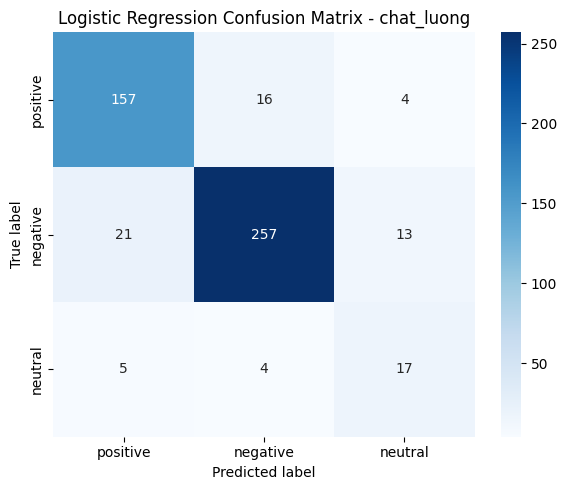

Saved confusion matrix to: d:\Workspace\b2\Machine learning 1\shopee-absa-ml-project\results\confusion_matrices\lr_chat_luong_confusion_matrix.png


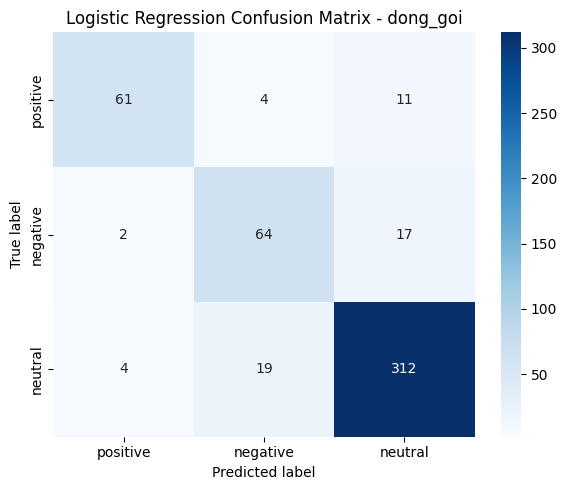

Saved confusion matrix to: d:\Workspace\b2\Machine learning 1\shopee-absa-ml-project\results\confusion_matrices\lr_dong_goi_confusion_matrix.png


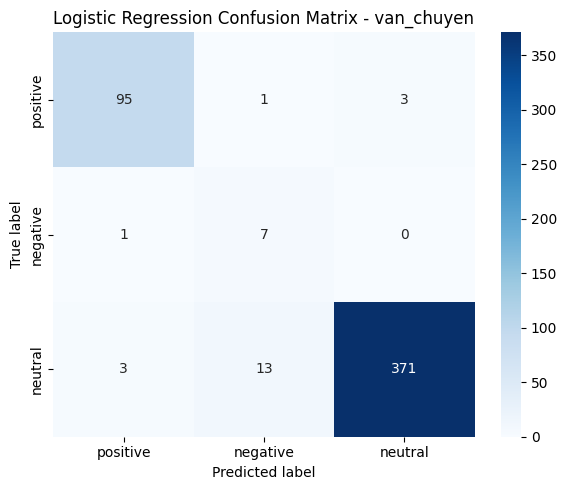

Saved confusion matrix to: d:\Workspace\b2\Machine learning 1\shopee-absa-ml-project\results\confusion_matrices\lr_van_chuyen_confusion_matrix.png


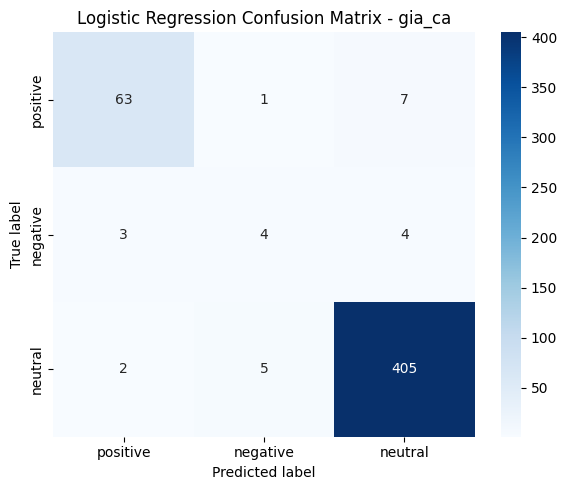

Saved confusion matrix to: d:\Workspace\b2\Machine learning 1\shopee-absa-ml-project\results\confusion_matrices\lr_gia_ca_confusion_matrix.png


In [66]:
labels = ["positive", "negative", "neutral"]

for aspect in aspect_columns:
    cm = lr_confusion_matrices[aspect]

    save_path = CONFUSION_MATRICES_DIR / f"lr_{aspect}_confusion_matrix.png"

    plot_confusion_matrix(
        cm=cm,
        labels=labels,
        title=f"Logistic Regression Confusion Matrix - {aspect}",
        save_path=save_path
    )

In [67]:
lr_prediction_df = test_df[["comment", "clean_comment"] + aspect_columns].copy()

for aspect in aspect_columns:
    lr_prediction_df[f"pred_{aspect}"] = lr_predictions[aspect]

lr_prediction_df.head()

,comment,clean_comment,chat_luong,dong_goi,van_chuyen,gia_ca,pred_chat_luong,pred_dong_goi,pred_van_chuyen,pred_gia_ca
0,sản phẩm chắc chắn xoay mượt. giá rẻ. giao siê...,sản phẩm chắc chắn xoay mượt giá rẻ giao siêu ...,negative,neutral,positive,positive,positive,neutral,positive,positive
1,nan ô mỏng bằng sợi tóc. ô nhỏ chán,nan ô mỏng bằng sợi tóc ô nhỏ chán,negative,neutral,neutral,neutral,negative,neutral,neutral,neutral
2,giao nhanh date mới date xa,giao nhanh date mới date xa,positive,neutral,positive,neutral,positive,neutral,positive,neutral
3,vợt cong vẹo lưới không căng rẻ tiền chịu thôi...,vợt cong vẹo lưới không căng rẻ tiền chịu thôi...,negative,negative,neutral,neutral,negative,negative,neutral,neutral
4,bình thường không có gì đặc biệt mua cao cấp c...,bình thường không có gì đặc biệt mua cao cấp c...,neutral,neutral,neutral,neutral,neutral,neutral,neutral,negative


In [68]:
LR_PREDICTIONS_PATH = RESULTS_DIR / "logistic_regression_predictions.csv"

lr_prediction_df.to_csv(
    LR_PREDICTIONS_PATH,
    index=False,
    encoding="utf-8-sig"
)

print("Saved Logistic Regression predictions to:", LR_PREDICTIONS_PATH)

Saved Logistic Regression predictions to: d:\Workspace\b2\Machine learning 1\shopee-absa-ml-project\results\logistic_regression_predictions.csv


In [69]:
for aspect in aspect_columns:
    lr_prediction_df[f"correct_{aspect}"] = (
        lr_prediction_df[aspect] == lr_prediction_df[f"pred_{aspect}"]
    )

correct_columns = [f"correct_{aspect}" for aspect in aspect_columns]

lr_prediction_df[["comment"] + correct_columns].head()

,comment,correct_chat_luong,correct_dong_goi,correct_van_chuyen,correct_gia_ca
0,sản phẩm chắc chắn xoay mượt. giá rẻ. giao siê...,False,True,True,True
1,nan ô mỏng bằng sợi tóc. ô nhỏ chán,True,True,True,True
2,giao nhanh date mới date xa,True,True,True,True
3,vợt cong vẹo lưới không căng rẻ tiền chịu thôi...,True,True,True,True
4,bình thường không có gì đặc biệt mua cao cấp c...,True,True,True,False


In [70]:
for aspect in aspect_columns:
    acc_manual = lr_prediction_df[f"correct_{aspect}"].mean()
    print(f"{aspect} manual accuracy:", round(acc_manual, 4))

chat_luong manual accuracy: 0.8725
dong_goi manual accuracy: 0.8846
van_chuyen manual accuracy: 0.9575
gia_ca manual accuracy: 0.9555


In [71]:
for aspect in aspect_columns:
    print(f"\nWrong predictions for aspect: {aspect}")

    wrong_examples = lr_prediction_df[
        lr_prediction_df[aspect] != lr_prediction_df[f"pred_{aspect}"]
    ][
        ["comment", "clean_comment", aspect, f"pred_{aspect}"]
    ]

    display(wrong_examples.head(5))


Wrong predictions for aspect: chat_luong


,comment,clean_comment,chat_luong,pred_chat_luong
0,sản phẩm chắc chắn xoay mượt. giá rẻ. giao siê...,sản phẩm chắc chắn xoay mượt giá rẻ giao siêu ...,negative,positive
20,hàng đẹp vải tốt mới nhận chưa dùng thử,hàng đẹp vải tốt mới nhận chưa dùng thử,positive,neutral
22,chất lượng tốt đúng mô tả không có sạc nhanh,chất lượng tốt đúng mô tả không có sạc nhanh,neutral,positive
29,bút dùng tốt không vấn đề gì,bút dùng tốt không vấn đề gì,positive,negative
39,vali không kín giá cao hơn bán ở chợ,vali không kín giá cao hơn bán ở chợ,negative,neutral



Wrong predictions for aspect: dong_goi


,comment,clean_comment,dong_goi,pred_dong_goi
17,ô ngắn gọn để vừa balo nhưng bề mặt cán nhám ấ...,ô ngắn gọn để vừa balo nhưng bề mặt cán nhám ấ...,negative,neutral
30,vali gọn bắt mắt khung gập không ổn lỏng lẻo x...,vali gọn bắt mắt khung gập không ổn lỏng lẻo x...,negative,neutral
37,gửi hàng kẹp 2 miếng bìa cường lực bể vỡ. nhắn...,gửi hàng kẹp 2 miếng bìa cường lực bể vỡ nhắn ...,negative,neutral
41,vợt bình thường vì giá rẻ nhưng cầu là cầu nhựa,vợt bình thường vì giá rẻ nhưng cầu là cầu nhựa,neutral,negative
47,hương vị thơm ngon dễ uống hộp chắc chắn tiện ...,hương vị thơm ngon dễ uống hộp chắc chắn tiện ...,positive,neutral



Wrong predictions for aspect: van_chuyen


,comment,clean_comment,van_chuyen,pred_van_chuyen
43,giao hàng không sạc pin sẵn,giao hàng không sạc pin sẵn,neutral,negative
61,mau hư hơn loại khác dùng 3 ngày sứt chỉ ngày ...,mau hư hơn loại khác dùng 3 ngày sứt chỉ ngày ...,positive,negative
77,vải lông thấm hút xọc xạch phải chịu khó để ý ...,vải lông thấm hút xọc xạch phải chịu khó để ý ...,positive,neutral
110,giao hàng cũ bị trầy xước nhiều,giao hàng cũ bị trầy xước nhiều,neutral,negative
127,shop đóng hàng nhanh kỹ sữa thơm ngon ít ngọt,shop đóng hàng nhanh kỹ sữa thơm ngon ít ngọt,neutral,positive



Wrong predictions for aspect: gia_ca


,comment,clean_comment,gia_ca,pred_gia_ca
4,bình thường không có gì đặc biệt mua cao cấp c...,bình thường không có gì đặc biệt mua cao cấp c...,neutral,negative
42,giá rẻ nhưng mút cứng,giá rẻ nhưng mút cứng,positive,negative
56,có 4g 1 tháng hết 4g không đọc báo được luôn. ...,có 4g 1 tháng hết 4g không đọc báo được luôn m...,negative,neutral
64,sữa thơm béo ít ngọt bao bì chắc chắn giá vừa ...,sữa thơm béo ít ngọt bao bì chắc chắn giá vừa ...,positive,neutral
65,"Không có đâu :))), Shop gian lận lượt đánh giá",không có đâu shop gian lận lượt đánh giá,neutral,negative


In [72]:
average_macro_f1 = lr_results_df["macro_f1"].mean()
average_weighted_f1 = lr_results_df["weighted_f1"].mean()

print("Average Macro F1 across 4 aspects:", round(average_macro_f1, 4))
print("Average Weighted F1 across 4 aspects:", round(average_weighted_f1, 4))

Average Macro F1 across 4 aspects: 0.7964
Average Weighted F1 across 4 aspects: 0.9197


In [73]:
overall_lr_summary = pd.DataFrame([
    {
        "model": "Logistic Regression",
        "average_macro_f1": average_macro_f1,
        "average_weighted_f1": average_weighted_f1
    }
])

overall_lr_summary[["average_macro_f1", "average_weighted_f1"]] = overall_lr_summary[
    ["average_macro_f1", "average_weighted_f1"]
].round(4)

overall_lr_summary

,model,average_macro_f1,average_weighted_f1
0,Logistic Regression,0.7964,0.9197


In [74]:
OVERALL_LR_SUMMARY_PATH = RESULTS_DIR / "logistic_regression_overall_summary.csv"

overall_lr_summary.to_csv(
    OVERALL_LR_SUMMARY_PATH,
    index=False,
    encoding="utf-8-sig"
)

print("Saved overall LR summary to:", OVERALL_LR_SUMMARY_PATH)

Saved overall LR summary to: d:\Workspace\b2\Machine learning 1\shopee-absa-ml-project\results\logistic_regression_overall_summary.csv


In [75]:
import sys

SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

from evaluate import evaluate_all_aspects

In [76]:
lr_results_df_from_module = evaluate_all_aspects(
    y_test=y_test,
    predictions=lr_predictions,
    aspect_columns=aspect_columns,
    model_name="Logistic Regression",
    results_dir=RESULTS_DIR
)

lr_results_df_from_module

,model,aspect,accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1
0,Logistic Regression,chat_luong,0.8725,0.7619,0.8080,0.7813,0.8802,0.8725,0.8754
1,Logistic Regression,dong_goi,0.8846,0.8546,0.8350,0.8435,0.8860,0.8846,0.8847
2,Logistic Regression,van_chuyen,0.9575,0.7616,0.9311,0.8058,0.9748,0.9575,0.9640
3,Logistic Regression,gia_ca,0.9555,0.7667,0.7447,0.7552,0.9540,0.9555,0.9546


In [77]:
lr_results_df_from_module.to_csv(
    RESULTS_DIR / "logistic_regression_results_from_module.csv",
    index=False,
    encoding="utf-8-sig"
)